In [4]:
''' First, get some helpful stuff out of the way '''
from __future__ import annotations # Useless pretty type-checking syntax

# Libraries we will use for I/O
%pip install matplotlib numpy -q
import csv
import matplotlib.pyplot as plt
import numpy as np

type coordinate = tuple[int, int]  # Convenient type alias for later
def display(c: coordinate) -> coordinate:
    ''' convert to 1-indexed coords for output '''
    return (c[0] + 1, c[1] + 1)

Note: you may need to restart the kernel to use updated packages.


In [ ]:
''' Now build the classes for our algorithm: '''
''' Neuron, Edge between adjacent Neurons,   '''
''' rectangular Grid of Neurons and Edges,   '''
''' and spike Table for storing results      '''

In [11]:
class Neuron:
    ''' Stateful Neuron model with membrane and recovery '''
    c: coordinate
    _I: int # synaptic input
    _v: int # potential
    _u: int # recovery
    edges_in: list[Edge]
    edges_out: list[Edge]

    def __init__(self, i: int | coordinate, j: int | None=None) -> Neuron:
        ''' Overloaded initializer, one tuple or two int arguments '''
        self.c = i if j is None else (i, j)
        self.edges_in = []
        self.edges_out = []
        self.reset()

    def update(self):
        ''' computes u(t+1), v(t+1) based on equations 2.1 and 2.2       '''
        ''' call after self.I is loaded with input from Edges this is in '''
        v, u = self._v, self._u # old values
        self._v = u + self._I
        self._u = -5 if v == 1 else min(u + 1, 0)
        self._I = 0 # reset

    def spiked(self) -> bool:
        return self._v >= 1

    def increment(self):
        self._I += 1

    def force_spike(self):
        self._v = 1

    def reset(self):
        self._I = 0
        self._v = 0
        self._u = 0

In [12]:
class Edge:
    ''' An Edge is a path between two neurons, from j to i '''
    ''' When j spikes, load i's input I                    '''
    i: Neuron
    j: Neuron
    D: int # axonal delay
    _d: int # delay counter

    def __init__(self, i: Neuron, j: Neuron, D: int) -> Edge:
        self.i = i
        self.j = j
        self.D = D
        self.reset()
        self.i.edges_in.append(self)
        self.j.edges_out.append(self)

    def update(self):
        # Update d based on j.v and equation 2.4
        self._d = self.D if self.j.spiked() else max(self._d - 1, 0)

        # Update i.I based on equation 2.3
        # Together, the Edges containing i will create the sum
        # and i's update() reset i.I after each time step
        if self._d == 1:
            self.i.increment()

    def reset(self):
        self._d = 0

In [13]:
class Grid:
    ''' Grid of Neurons and Edges for wavefront to propagate through '''
    ''' n rows by m columns grid of neurons and edges                '''
    ''' Does not keep track of time, that is algorithm's job         '''
    n: int
    m: int
    grid: list[list[Neuron]]
    edges: list[Edge]

    def __init__(self, n: int, m: int) -> Grid:
        ''' Initialize grid of neurons and edges without delays D_ij'''
        grid = []
        edges = []
        self.n = n
        self.m = m

        # Create grid of neurons
        for i in range(n):
            row = []
            for j in range(m):
                row.append(Neuron(i, j))
            grid.append(row)

        # Initialize east-west edges
        for j in range(m):
            for i in range(n-1):
                edge = Edge(grid[i][j], grid[i+1][j], 1)
                edges.append(edge)
                bedge = Edge(grid[i+1][j], grid[i][j], 1)
                edges.append(bedge)

        # Initialize north-south edges
        for i in range(n):
            for j in range(m-1):
                edge = Edge(grid[i][j], grid[i][j+1], 1)
                edges.append(edge)
                bedge = Edge(grid[i][j+1], grid[i][j], 1)
                edges.append(bedge)

        self.grid = grid
        self.edges = edges

    def load_delays(self, delays_in: list[list[int]]):
        ''' Add delays to edges, assuming that the delay to each  '''
        ''' neuron is the same and given by n x m array delays_in '''
        for i in range(self.n):
            for j in range(self.m):
                for e in self.get_neuron(i, j).edges_in:
                    e.D = delays_in[i][j]

    def get_neuron(self, n: int | coordinate, m: int | None=None) -> Neuron:
        ''' Overloaded neuron getter, one tuple or two int arguments '''
        if m is None:
            return self.grid[n[0]][n[1]]
        else:
            return self.grid[n][m]

    def reset(self):
        ''' Reset grid by resetting all neurons '''
        [e.reset() for e in self.edges]
        [n.reset() for row in self.grid for n in row]

    def update(self):
        ''' Update edges then neurons '''
        [e.update() for e in self.edges]
        [n.update() for row in self.grid for n in row]

    def get_spiked(self) -> list[Neuron]:
        ''' Returns all neurons that have spiked this time step '''
        return [n for row in self.grid for n in row if n.spiked()]

In [14]:
class Table:
    ''' Spike table for logging events in wavefront propagation algorithm '''
    n: int # rows
    m: int # cols
    times: list[int]
    neurons: list[Neuron] # can have repeats
    entries: list[tuple[int, Neuron]]
    first_spikes: list[list[int | None]]

    def __init__(self, n: int, m: int) -> Table:
        self.n = n
        self.m = m
        self.times = []
        self.neurons = []
        self.entries = []
        self.first_spikes = [[None for i in range(n)] for i in range(m)]

    def append(self, time: int, neuron: Neuron):
        self.times.append(time)
        self.neurons.append(neuron)
        self.entries.append((time, neuron))

        i, j = neuron.c
        if self.first_spikes[i][j] is None:
            self.first_spikes[i][j] = time

    def spike_time(self, c: coordinate) -> int:
        return self.first_spikes[c[0]][c[1]]

    def path(self, start: coordinate | None=None, goal: coordinate | None=None) -> list[coordinate]:
        ''' Backtrace path from goal to start (with defaults) then reverse '''
        if start is None: start = (0, 0)
        if goal is None: goal = (self.n-1, self.m-1)

        ret = [goal]
        cur = goal
        while cur != start:
            # Get adjacent neighbors
            adj = [
                (cur[0] + 1, cur[1]),
                (cur[0] - 1, cur[1]),
                (cur[0], cur[1] + 1),
                (cur[0], cur[1] - 1),
            ]

            # Remove out-of-bounds neighbors
            adj = [a for a in adj if 0 <= a[0] < self.n and 0 <= a[1] < self.m]

            # Go to neighbor with lowest first spike time
            for a in adj:
                t = self.spike_time(a)
                if t is not None and t < self.spike_time(cur):
                    cur = a
            ret.insert(0, cur)
        return ret

    def print(self):
        for t, n in zip(self.times, self.neurons):
            print(f"Time:  {t}\tNeuron: {display(n.c)}")

In [15]:
''' Some helpers for grids '''
def csv_to_grid(path: str) -> Grid:
    try:
        with open(path, 'r') as f:
            reader = csv.reader(f)
            delays = list(reader)
    except FileNotFoundError:
        panic(f"csv_to_grid: file {path} not found")

    if not delays or not delays[0]:
        panic(f"csv_to_grid: {path} csv reader was empty")

    delays = [[int(x) for x in row] for row in delays]
    grid = Grid(len(delays), len(delays[0]))
    grid.load_delays(delays)
    return grid

def uniform_grid(n: int, m: int, delay: int) -> Grid:
    grid = Grid(n, m)
    delays = []
    for i in range(n):
        row = []
        for j in range(m):
            row.append(delay)
        delays.append(row)

    grid.load_delays(delays)
    return grid

def heatmap(table: Table, path: bool=False):
    ''' heatmap of first spike times with shortest path overlaid '''
    data = np.array(
        [[np.nan if t is None else t for t in row] for row in table.first_spikes],
        dtype=float,
    )

    fig, ax = plt.subplots()
    im = ax.imshow(data, cmap='viridis', origin='upper')
    fig.colorbar(im, ax=ax, label='first spike time')

    # 1-indexed tick labels; imshow positions stay 0-based
    ax.set_xticks(range(table.m))
    ax.set_yticks(range(table.n))
    ax.set_xticklabels(range(1, table.m + 1))
    ax.set_yticklabels(range(1, table.n + 1))

    if path:
        rows, cols = zip(*table.path())  # (i, j) -> y, x for imshow
        ax.plot(cols, rows, color='red', linewidth=2, markersize=4)
        ax.plot(cols[0], rows[0], 'go', markersize=8)   # start
        ax.plot(cols[-1], rows[-1], 'rs', markersize=8)  # goal

    plt.show()

In [16]:
''' Now, establish our actual wavefront propagation algorithm '''
def propagate(grid: Grid, start: coordinate | None=None, goal: coordinate | None=None) -> Table:
    ''' Given a grid loaded with delays, propagate a spiking '''
    ''' wave from start to goal and return a spike table     '''
    if start is None: start = (0, 0)
    if goal is None: goal = (grid.n-1, grid.m-1)

    grid.reset()
    time = 0
    table = Table(grid.n, grid.m)
    s = grid.get_neuron(start)
    g = grid.get_neuron(goal)

    # Start wavefront by spiking s
    s.force_spike()
    table.append(time, s)
    # Timestep until g spikes
    while not g.spiked():
        time += 1
        grid.update()
        for neuron in grid.get_spiked():
            table.append(time, neuron)

    print("Spike table:")
    table.print()
    
    print("Goal neuron spiked at time t =", time)
    print("Total spikes:", len(table.entries))
    print("Shortest path:", [display(c) for c in table.path()])
    print("First spike time heatmaps:")
    heatmap(table, False)
    heatmap(table, True)
    return table

Spike table:
Time:  0	Neuron: (1, 1)
Time:  10	Neuron: (1, 2)
Time:  10	Neuron: (2, 1)
Time:  20	Neuron: (1, 1)
Time:  20	Neuron: (1, 3)
Time:  20	Neuron: (2, 2)
Time:  20	Neuron: (3, 1)
Time:  30	Neuron: (1, 2)
Time:  30	Neuron: (1, 4)
Time:  30	Neuron: (2, 1)
Time:  30	Neuron: (2, 3)
Time:  30	Neuron: (3, 2)
Time:  30	Neuron: (4, 1)
Time:  40	Neuron: (1, 1)
Time:  40	Neuron: (1, 3)
Time:  40	Neuron: (2, 2)
Time:  40	Neuron: (2, 4)
Time:  40	Neuron: (3, 1)
Time:  40	Neuron: (3, 3)
Time:  40	Neuron: (4, 2)
Time:  50	Neuron: (1, 2)
Time:  50	Neuron: (1, 4)
Time:  50	Neuron: (2, 1)
Time:  50	Neuron: (2, 3)
Time:  50	Neuron: (3, 2)
Time:  50	Neuron: (3, 4)
Time:  50	Neuron: (4, 1)
Time:  50	Neuron: (4, 3)
Time:  60	Neuron: (1, 1)
Time:  60	Neuron: (1, 3)
Time:  60	Neuron: (2, 2)
Time:  60	Neuron: (2, 4)
Time:  60	Neuron: (3, 1)
Time:  60	Neuron: (3, 3)
Time:  60	Neuron: (4, 2)
Time:  60	Neuron: (4, 4)
Goal neuron spiked at time t = 60
Total spikes: 36
Shortest path: [(1, 1), (1, 2), (1, 3

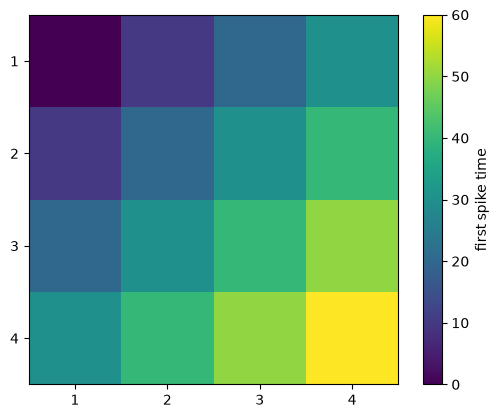

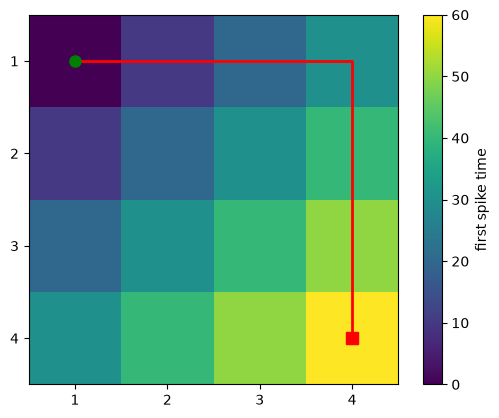

In [18]:
''' Now run on uniform grid '''
n, m, d = 4, 4, 10 # 4x4 grid, uniform cost of 10
grid = uniform_grid(n, m, d)
table = propagate(grid)

Spike table:
Time:  0	Neuron: (1, 1)
Time:  1	Neuron: (1, 2)
Time:  2	Neuron: (1, 3)
Time:  3	Neuron: (1, 4)
Time:  4	Neuron: (1, 5)
Time:  5	Neuron: (1, 6)
Time:  6	Neuron: (1, 7)
Time:  7	Neuron: (1, 8)
Time:  7	Neuron: (2, 7)
Time:  8	Neuron: (2, 8)
Time:  8	Neuron: (3, 7)
Time:  9	Neuron: (3, 6)
Time:  9	Neuron: (3, 8)
Time:  10	Neuron: (2, 8)
Time:  10	Neuron: (3, 5)
Time:  11	Neuron: (3, 4)
Time:  11	Neuron: (3, 8)
Time:  11	Neuron: (4, 5)
Time:  12	Neuron: (3, 3)
Time:  12	Neuron: (4, 4)
Time:  13	Neuron: (3, 2)
Time:  13	Neuron: (4, 3)
Time:  14	Neuron: (3, 1)
Time:  14	Neuron: (4, 2)
Time:  14	Neuron: (4, 4)
Time:  15	Neuron: (4, 1)
Time:  15	Neuron: (4, 3)
Time:  15	Neuron: (5, 2)
Time:  16	Neuron: (4, 2)
Time:  16	Neuron: (5, 1)
Time:  16	Neuron: (6, 2)
Time:  17	Neuron: (4, 1)
Time:  17	Neuron: (4, 3)
Time:  17	Neuron: (6, 1)
Time:  17	Neuron: (6, 3)
Time:  17	Neuron: (7, 2)
Time:  18	Neuron: (4, 2)
Time:  18	Neuron: (5, 1)
Time:  18	Neuron: (6, 4)
Time:  18	Neuron: (7, 1)


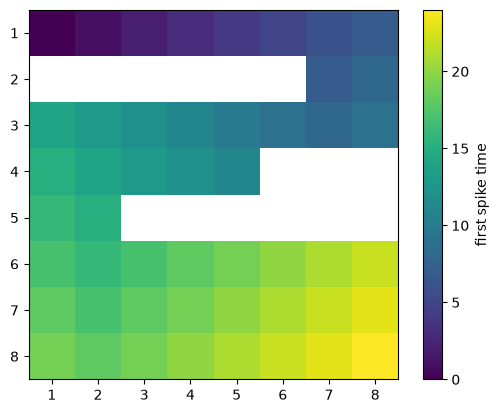

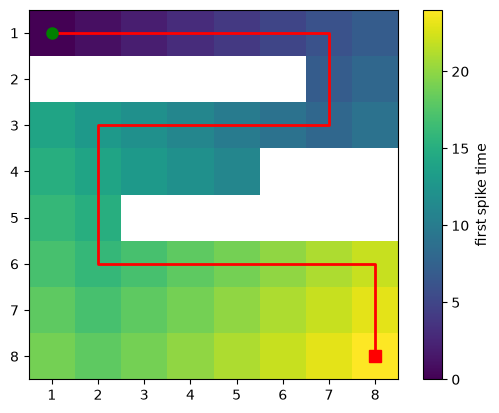

In [19]:
''' Now, run on our csv-defined cost map '''
grid = csv_to_grid('cost_map_8x8.csv')
table = propagate(grid)

In [5]:
''' Finally, verify against Dijkstra's '''
import numpy as np

cost_map = np.loadtxt("cost_map_8x8.csv", delimiter=",")

rows, cols = cost_map.shape
start = (0,0)
goal = (7,7)

directions = [
    (-1,0),
    (1,0),
    (0,-1),
    (0,1)
]

dist = {}
prev = {}
Q = []

#initialize
for r in range(rows): 
    for c in range(cols):
        vertex = (r, c)

        dist[vertex] = float('inf')
        prev[vertex] = None
        Q.append(vertex)

dist[start] = 0

while Q: 
    u = min(Q, key=lambda vertex: dist[vertex])
    Q.remove(u)
    if u == goal: 
        break

    row, col = u

    for dr, dc in directions: 
        nr = row + dr
        nc = col + dc

        if 0 <= nr < rows and 0 <= nc < cols: 
            v = (nr, nc)

            if v not in Q: 
                continue

            alt = dist[u] + cost_map[nr, nc]

            if alt < dist[v]: 
                dist[v] = alt
                prev[v] = u

path = []
current = goal
while current is not None: 
    path.append(current)
    current = prev[current]
path.reverse()

print("Shortest path:", [display(c) for c in path])
print()
print("Total path cost:", dist[goal])
print()
print("Path length:", len(path))

Shortest path: [(1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (2, 7), (3, 7), (3, 6), (3, 5), (3, 4), (3, 3), (3, 2), (4, 2), (5, 2), (6, 2), (6, 3), (6, 4), (6, 5), (6, 6), (6, 7), (6, 8), (7, 8), (8, 8)]

Total path cost: 24.0

Path length: 25
